# Exploratory Data Analysis (EDA) Profundo - Dataset Curves

## Parte 4: Analisis de Anomalias, Calidad de Datos y Visualizaciones Avanzadas

Este notebook realiza deteccion de outliers, analisis de calidad de datos, y visualizaciones avanzadas del dataset.

---

### Tabla de Contenidos
1. Deteccion de Outliers Estadisticos
2. Analisis de Calidad de Discretizacion
3. Deteccion de Curvas Anomalas
4. Visualizaciones de Galeria de Curvas
5. Analisis de Densidad y Distribucion Espacial
6. Comparativa Multi-Resolucion
7. Metricas de Error Pixel vs Target

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path
from scipy import stats, spatial
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# Configuracion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 10

# Rutas
BASE_PATH = Path('..')
PIXEL_CURVES_PATH = BASE_PATH / 'datos' / 'pixel_curves'
TARGET_PATH = BASE_PATH / 'datos' / 'target'

print("Librerias cargadas")

Librerias cargadas


In [2]:
# Funciones de carga
def load_target_curve(curve_id):
    filepath = TARGET_PATH / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(filepath, delimiter=',')
    return data[:, 0], data[:, 1]

def load_pixel_curve(curve_id, x_value):
    filepath = PIXEL_CURVES_PATH / f'curve_{curve_id:04d}_X{x_value}.txt'
    data = np.loadtxt(filepath)
    return data[:, 0], data[:, 1]

# Cargar datos
print("Cargando datos...")
target_data = {}
for i in range(1, 501):
    x, y = load_target_curve(i)
    target_data[i] = {'x': x, 'y': y}

pixel_data = defaultdict(dict)
x_values = [10, 15, 18, 21, 25]
for x_val in x_values:
    for i in range(1, 501):
        px, py = load_pixel_curve(i, x_val)
        pixel_data[x_val][i] = {'x': px, 'y': py}

print(f"Cargadas {len(target_data)} curvas target y {sum(len(pixel_data[x]) for x in x_values)} curvas pixel")

Cargando datos...
Cargadas 500 curvas target y 2500 curvas pixel


---
## 1. Deteccion de Outliers Estadisticos

In [3]:
def calculate_curve_features(x, y):
    """Extrae caracteristicas para deteccion de outliers."""
    dx = np.diff(x)
    dy = np.diff(y)
    segment_lengths = np.sqrt(dx**2 + dy**2)
    
    return {
        'arc_length': np.sum(segment_lengths),
        'x_range': x.max() - x.min(),
        'y_range': y.max() - y.min(),
        'x_mean': x.mean(),
        'y_mean': y.mean(),
        'x_std': x.std(),
        'y_std': y.std(),
        'aspect_ratio': (x.max() - x.min()) / max(y.max() - y.min(), 1),
        'centroid_x': x.mean(),
        'centroid_y': y.mean()
    }

print("DETECCION DE OUTLIERS ESTADISTICOS")
print("=" * 70)

# Extraer caracteristicas
features_list = []
for curve_id, data in target_data.items():
    features = calculate_curve_features(data['x'], data['y'])
    features['curve_id'] = curve_id
    features_list.append(features)

df_features = pd.DataFrame(features_list)

# Detectar outliers usando Z-score
def detect_outliers_zscore(df, columns, threshold=3):
    """Detecta outliers usando Z-score."""
    outliers = pd.DataFrame()
    for col in columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers[col] = z_scores > threshold
    return outliers

numeric_cols = ['arc_length', 'x_range', 'y_range', 'x_std', 'y_std', 'aspect_ratio']
outliers_zscore = detect_outliers_zscore(df_features, numeric_cols)

# Contar outliers por curva
outlier_count = outliers_zscore.sum(axis=1)
df_features['n_outlier_features'] = outlier_count

print("\nDistribucion de caracteristicas outlier por curva:")
print(df_features['n_outlier_features'].value_counts().sort_index())

DETECCION DE OUTLIERS ESTADISTICOS

Distribucion de caracteristicas outlier por curva:
n_outlier_features
0    495
1      3
2      1
3      1
Name: count, dtype: int64


In [4]:
# Identificar curvas con mas caracteristicas outlier
print("\nCurvas con caracteristicas outlier (Z-score > 3):")
outlier_curves = df_features[df_features['n_outlier_features'] > 0].sort_values('n_outlier_features', ascending=False)

if len(outlier_curves) > 0:
    print(f"\nTotal de curvas con al menos 1 caracteristica outlier: {len(outlier_curves)}")
    print("\nTop 10 curvas con mas caracteristicas outlier:")
    print(outlier_curves[['curve_id', 'n_outlier_features', 'arc_length', 'x_range', 'y_range']].head(10).to_string(index=False))
else:
    print("No se encontraron curvas con caracteristicas outlier (Z-score > 3)")


Curvas con caracteristicas outlier (Z-score > 3):

Total de curvas con al menos 1 caracteristica outlier: 5

Top 10 curvas con mas caracteristicas outlier:
 curve_id  n_outlier_features  arc_length    x_range    y_range
      360                   3   81.186951  78.831483   7.736636
       92                   2  307.287663 230.602372 110.895357
      295                   1  239.287617 210.119794  81.145373
      297                   1  268.222228 247.656528  30.943750
      378                   1  196.848573 184.494387  23.278483


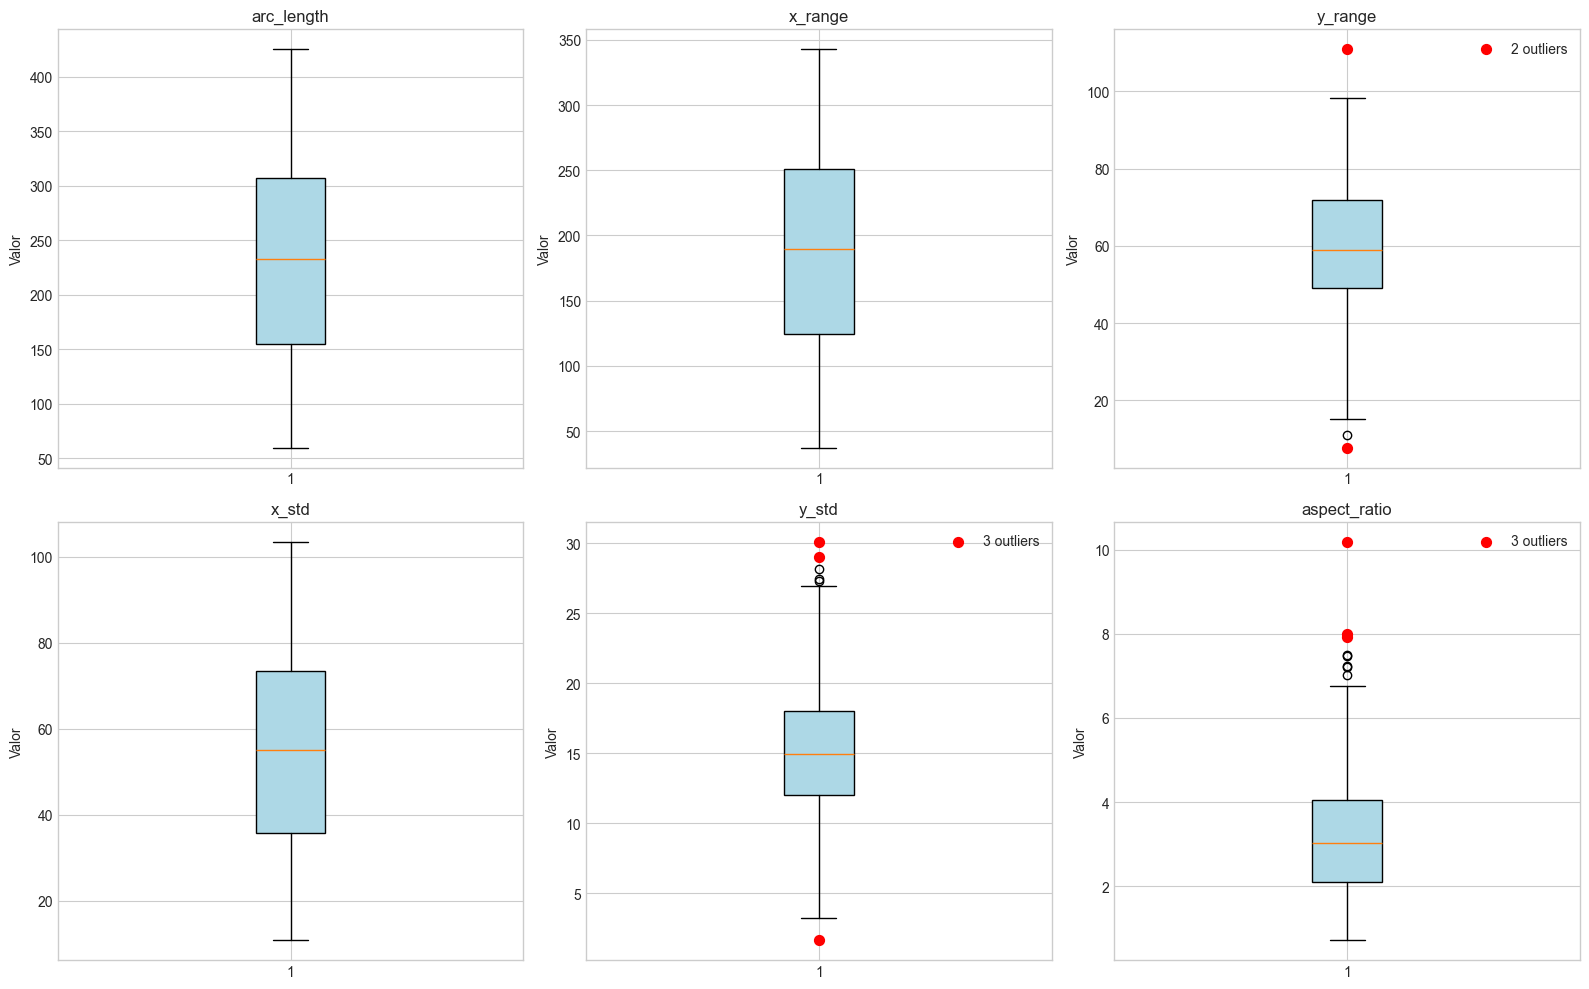

In [5]:
# Visualizacion de outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3, idx % 3]
    
    # Boxplot
    bp = ax.boxplot(df_features[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    
    # Marcar outliers
    outlier_values = df_features[outliers_zscore[col]][col]
    ax.scatter([1] * len(outlier_values), outlier_values, color='red', s=50, zorder=5, label=f'{len(outlier_values)} outliers')
    
    ax.set_title(f'{col}')
    ax.set_ylabel('Valor')
    if len(outlier_values) > 0:
        ax.legend()

plt.tight_layout()
plt.savefig('outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

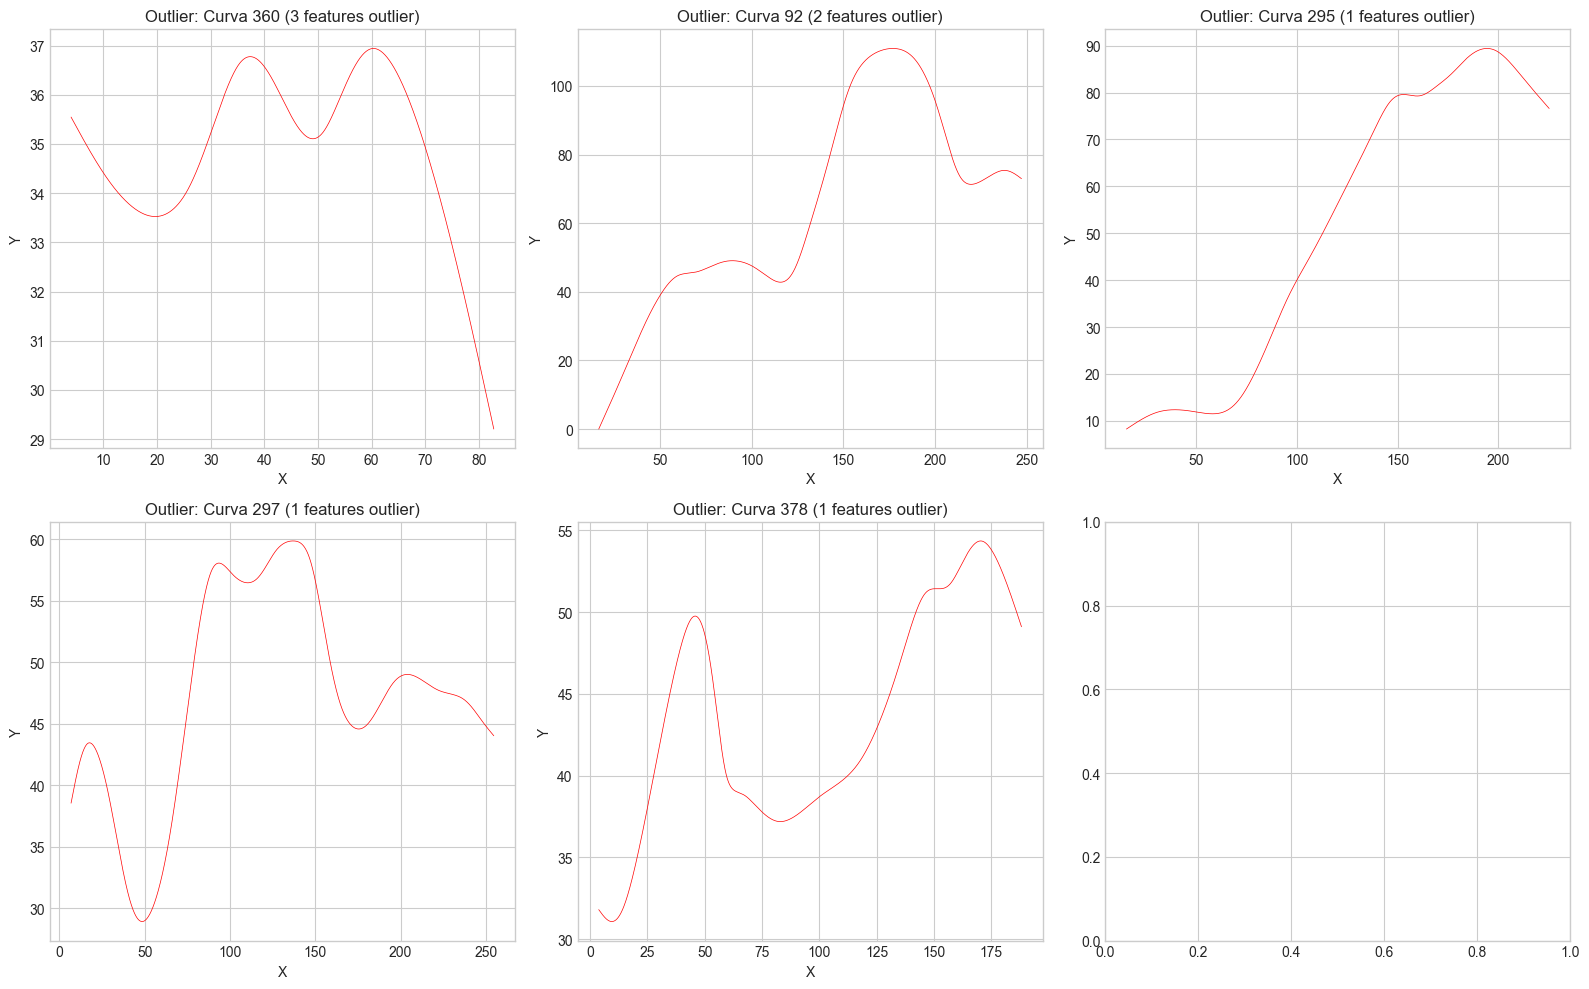

In [6]:
# Visualizar curvas outlier
if len(outlier_curves) > 0:
    n_to_show = min(6, len(outlier_curves))
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for idx, (_, row) in enumerate(outlier_curves.head(n_to_show).iterrows()):
        ax = axes[idx // 3, idx % 3]
        curve_id = int(row['curve_id'])
        x, y = target_data[curve_id]['x'], target_data[curve_id]['y']
        
        ax.plot(x, y, linewidth=0.5, color='red')
        ax.set_title(f'Outlier: Curva {curve_id} ({int(row["n_outlier_features"])} features outlier)')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
    
    plt.tight_layout()
    plt.savefig('curvas_outlier.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 2. Analisis de Calidad de Discretizacion

In [7]:
def analyze_discretization_quality(target_x, target_y, pixel_x, pixel_y):
    """Analiza la calidad de la discretizacion pixel respecto al target."""
    # Verificar valores unicos (deberian ser enteros)
    pixel_x_unique = len(np.unique(pixel_x))
    pixel_y_unique = len(np.unique(pixel_y))
    
    # Verificar que sean enteros
    is_integer_x = np.all(pixel_x == pixel_x.astype(int))
    is_integer_y = np.all(pixel_y == pixel_y.astype(int))
    
    # Verificar espaciado uniforme
    dx = np.diff(pixel_x)
    dy = np.diff(pixel_y)
    
    # Saltos mayores a 1 pixel
    large_jumps_x = np.sum(np.abs(dx) > 1)
    large_jumps_y = np.sum(np.abs(dy) > 1)
    
    # Ratio de compresion
    compression_ratio = len(pixel_x) / len(target_x)
    
    return {
        'pixel_x_unique': pixel_x_unique,
        'pixel_y_unique': pixel_y_unique,
        'is_integer_x': is_integer_x,
        'is_integer_y': is_integer_y,
        'large_jumps_x': large_jumps_x,
        'large_jumps_y': large_jumps_y,
        'compression_ratio': compression_ratio
    }

print("ANALISIS DE CALIDAD DE DISCRETIZACION")
print("=" * 70)

# Analizar discretizacion para cada variante
quality_stats = defaultdict(list)

for x_val in x_values:
    for curve_id in range(1, 501):
        t_x, t_y = target_data[curve_id]['x'], target_data[curve_id]['y']
        p_x, p_y = pixel_data[x_val][curve_id]['x'], pixel_data[x_val][curve_id]['y']
        
        quality = analyze_discretization_quality(t_x, t_y, p_x, p_y)
        quality['curve_id'] = curve_id
        quality['x_variant'] = x_val
        quality_stats[x_val].append(quality)

# Convertir a DataFrames
df_quality = {x: pd.DataFrame(quality_stats[x]) for x in x_values}

ANALISIS DE CALIDAD DE DISCRETIZACION


In [8]:
# Resumen de calidad por variante
print("\nResumen de calidad de discretizacion por variante:")
print("-" * 80)

for x_val in x_values:
    df = df_quality[x_val]
    print(f"\nX{x_val}:")
    print(f"  Todos valores enteros en X: {df['is_integer_x'].all()}")
    print(f"  Todos valores enteros en Y: {df['is_integer_y'].all()}")
    print(f"  Ratio compresion promedio: {df['compression_ratio'].mean():.4f}")
    print(f"  Saltos grandes X (>1px) promedio: {df['large_jumps_x'].mean():.1f}")
    print(f"  Saltos grandes Y (>1px) promedio: {df['large_jumps_y'].mean():.1f}")


Resumen de calidad de discretizacion por variante:
--------------------------------------------------------------------------------

X10:
  Todos valores enteros en X: True
  Todos valores enteros en Y: True
  Ratio compresion promedio: 0.0252
  Saltos grandes X (>1px) promedio: 0.0
  Saltos grandes Y (>1px) promedio: 0.0

X15:
  Todos valores enteros en X: True
  Todos valores enteros en Y: True
  Ratio compresion promedio: 0.0378
  Saltos grandes X (>1px) promedio: 0.0
  Saltos grandes Y (>1px) promedio: 0.0

X18:
  Todos valores enteros en X: True
  Todos valores enteros en Y: True
  Ratio compresion promedio: 0.0453
  Saltos grandes X (>1px) promedio: 0.0
  Saltos grandes Y (>1px) promedio: 0.0

X21:
  Todos valores enteros en X: True
  Todos valores enteros en Y: True
  Ratio compresion promedio: 0.0529
  Saltos grandes X (>1px) promedio: 0.0
  Saltos grandes Y (>1px) promedio: 0.0

X25:
  Todos valores enteros en X: True
  Todos valores enteros en Y: True
  Ratio compresion prom

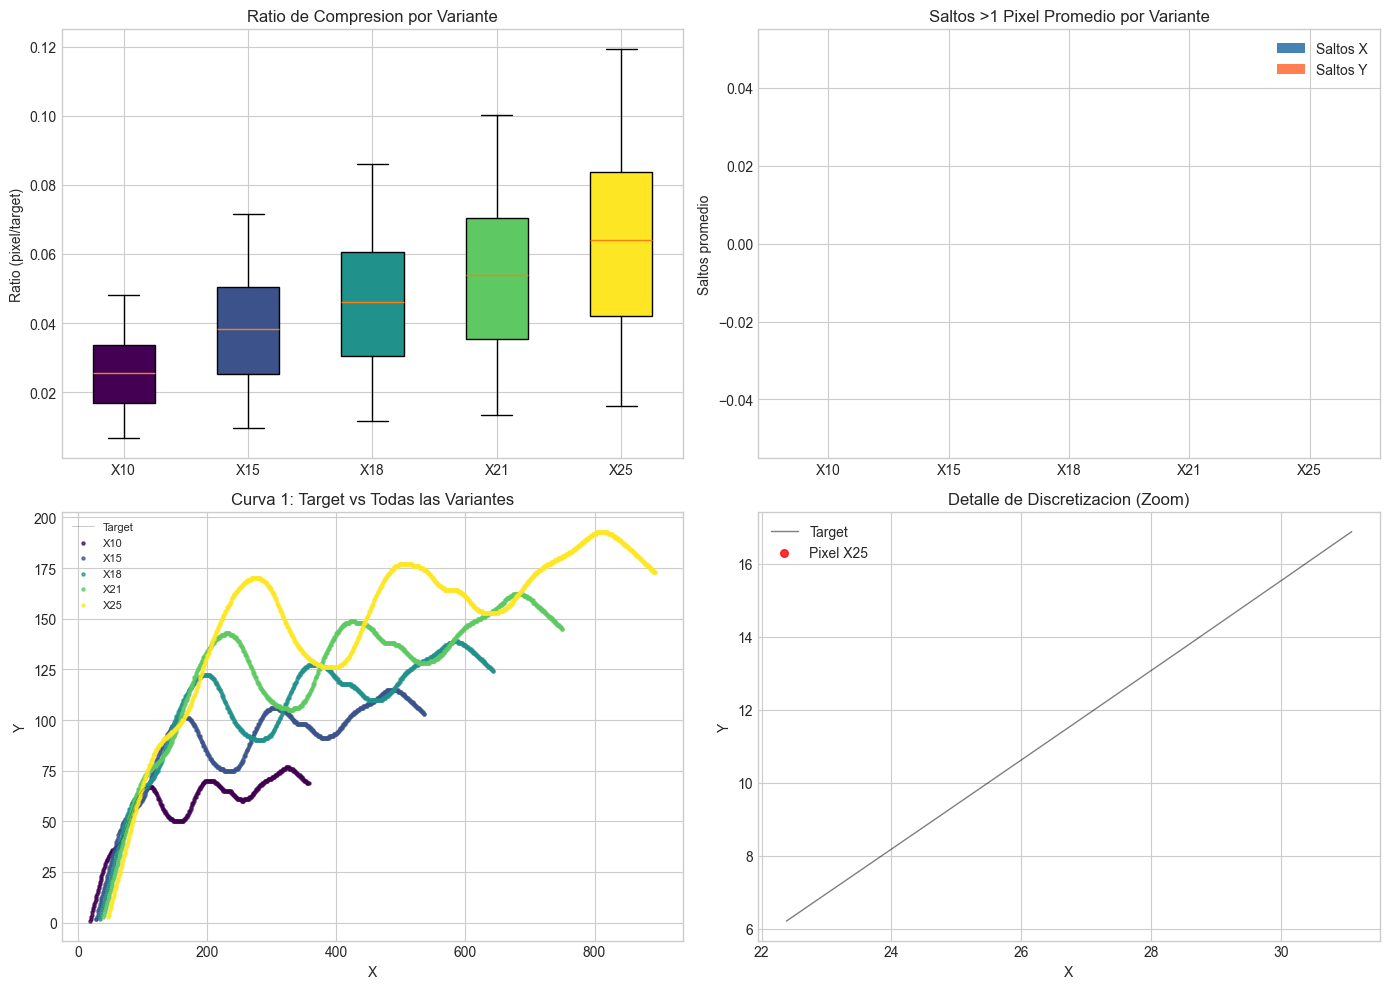

In [9]:
# Visualizacion de calidad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ratio de compresion por variante
compression_data = [df_quality[x]['compression_ratio'] for x in x_values]
bp1 = axes[0, 0].boxplot(compression_data, labels=[f'X{x}' for x in x_values], patch_artist=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(x_values)))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 0].set_title('Ratio de Compresion por Variante')
axes[0, 0].set_ylabel('Ratio (pixel/target)')

# Saltos grandes
large_jumps_x = [df_quality[x]['large_jumps_x'].mean() for x in x_values]
large_jumps_y = [df_quality[x]['large_jumps_y'].mean() for x in x_values]

x_pos = np.arange(len(x_values))
width = 0.35
axes[0, 1].bar(x_pos - width/2, large_jumps_x, width, label='Saltos X', color='steelblue')
axes[0, 1].bar(x_pos + width/2, large_jumps_y, width, label='Saltos Y', color='coral')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([f'X{x}' for x in x_values])
axes[0, 1].set_title('Saltos >1 Pixel Promedio por Variante')
axes[0, 1].set_ylabel('Saltos promedio')
axes[0, 1].legend()

# Ejemplo visual: misma curva en diferentes resoluciones
example_id = 1
ax = axes[1, 0]
t_x, t_y = target_data[example_id]['x'], target_data[example_id]['y']
ax.plot(t_x, t_y, 'k-', linewidth=0.5, alpha=0.3, label='Target')

for idx, x_val in enumerate(x_values):
    p_x, p_y = pixel_data[x_val][example_id]['x'], pixel_data[x_val][example_id]['y']
    ax.scatter(p_x, p_y, s=5, alpha=0.7, label=f'X{x_val}', color=colors[idx])

ax.set_title(f'Curva {example_id}: Target vs Todas las Variantes')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(fontsize=8)

# Detalle de discretizacion
ax = axes[1, 1]
# Zoom en una seccion
zoom_start, zoom_end = 100, 300
t_x, t_y = target_data[example_id]['x'][zoom_start:zoom_end], target_data[example_id]['y'][zoom_start:zoom_end]
ax.plot(t_x, t_y, 'k-', linewidth=1, alpha=0.5, label='Target')

p_x, p_y = pixel_data[25][example_id]['x'], pixel_data[25][example_id]['y']
# Filtrar puntos en el rango
mask = (p_x >= t_x.min()) & (p_x <= t_x.max())
ax.scatter(p_x[mask], p_y[mask], s=30, color='red', alpha=0.8, label='Pixel X25', zorder=5)

ax.set_title('Detalle de Discretizacion (Zoom)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

plt.tight_layout()
plt.savefig('calidad_discretizacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Deteccion de Curvas Anomalas

In [10]:
def detect_anomalies(x, y):
    """Detecta anomalias en una curva."""
    anomalies = []
    
    # 1. Verificar puntos duplicados consecutivos
    dx = np.diff(x)
    dy = np.diff(y)
    duplicates = np.sum((dx == 0) & (dy == 0))
    if duplicates > 0:
        anomalies.append(f'puntos_duplicados: {duplicates}')
    
    # 2. Verificar saltos bruscos (outliers en distancia)
    distances = np.sqrt(dx**2 + dy**2)
    mean_dist = np.mean(distances)
    std_dist = np.std(distances)
    outlier_jumps = np.sum(distances > mean_dist + 5*std_dist)
    if outlier_jumps > 0:
        anomalies.append(f'saltos_bruscos: {outlier_jumps}')
    
    # 3. Verificar valores extremos
    if x.min() < -1000 or x.max() > 10000:
        anomalies.append('x_extremo')
    if y.min() < -1000 or y.max() > 10000:
        anomalies.append('y_extremo')
    
    # 4. Verificar NaN o Inf
    if np.any(np.isnan(x)) or np.any(np.isnan(y)):
        anomalies.append('contiene_nan')
    if np.any(np.isinf(x)) or np.any(np.isinf(y)):
        anomalies.append('contiene_inf')
    
    return anomalies

print("DETECCION DE CURVAS ANOMALAS")
print("=" * 70)

# Analizar todas las curvas target
anomaly_report = []
for curve_id, data in target_data.items():
    anomalies = detect_anomalies(data['x'], data['y'])
    if anomalies:
        anomaly_report.append({'curve_id': curve_id, 'anomalies': '; '.join(anomalies), 'n_anomalies': len(anomalies)})

if anomaly_report:
    df_anomalies = pd.DataFrame(anomaly_report)
    print(f"\nCurvas con anomalias detectadas: {len(df_anomalies)}")
    print("\nDetalle:")
    print(df_anomalies.to_string(index=False))
else:
    print("\nNo se detectaron anomalias en las curvas target.")

DETECCION DE CURVAS ANOMALAS

No se detectaron anomalias en las curvas target.


In [11]:
# Analizar curvas pixel
print("\nAnalisis de anomalias en curvas pixel:")
pixel_anomalies = defaultdict(list)

for x_val in x_values:
    for curve_id in range(1, 501):
        p_x, p_y = pixel_data[x_val][curve_id]['x'], pixel_data[x_val][curve_id]['y']
        anomalies = detect_anomalies(p_x, p_y)
        if anomalies:
            pixel_anomalies[x_val].append({'curve_id': curve_id, 'anomalies': anomalies})

for x_val in x_values:
    n_anomalies = len(pixel_anomalies[x_val])
    print(f"  X{x_val}: {n_anomalies} curvas con anomalias")


Analisis de anomalias en curvas pixel:
  X10: 0 curvas con anomalias
  X15: 0 curvas con anomalias
  X18: 0 curvas con anomalias
  X21: 0 curvas con anomalias
  X25: 0 curvas con anomalias


---
## 4. Galeria de Curvas

GALERIA DE CURVAS


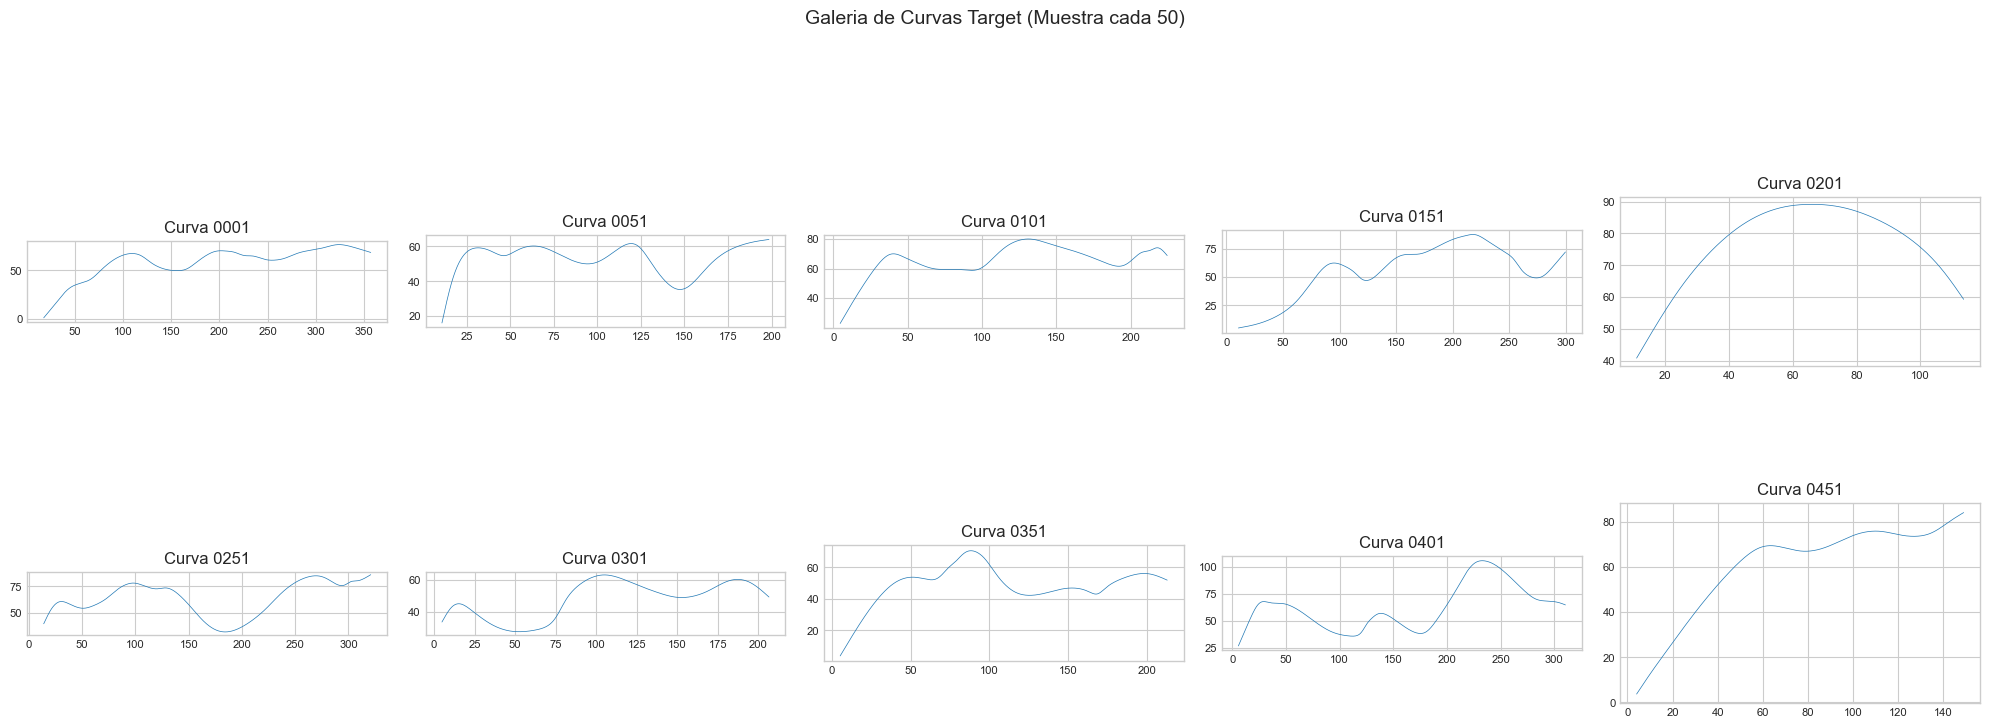

In [12]:
# Galeria de curvas representativas
print("GALERIA DE CURVAS")
print("=" * 70)

# Seleccionar curvas representativas cada N
sample_ids = list(range(1, 501, 50))  # Cada 50 curvas

n_cols = 5
n_rows = (len(sample_ids) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for idx, curve_id in enumerate(sample_ids):
    ax = axes[idx]
    x, y = target_data[curve_id]['x'], target_data[curve_id]['y']
    ax.plot(x, y, linewidth=0.5)
    ax.set_title(f'Curva {curve_id:04d}')
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)

# Ocultar ejes sobrantes
for idx in range(len(sample_ids), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Galeria de Curvas Target (Muestra cada 50)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('galeria_curvas.png', dpi=150, bbox_inches='tight')
plt.show()


Generando mosaico de todas las curvas...


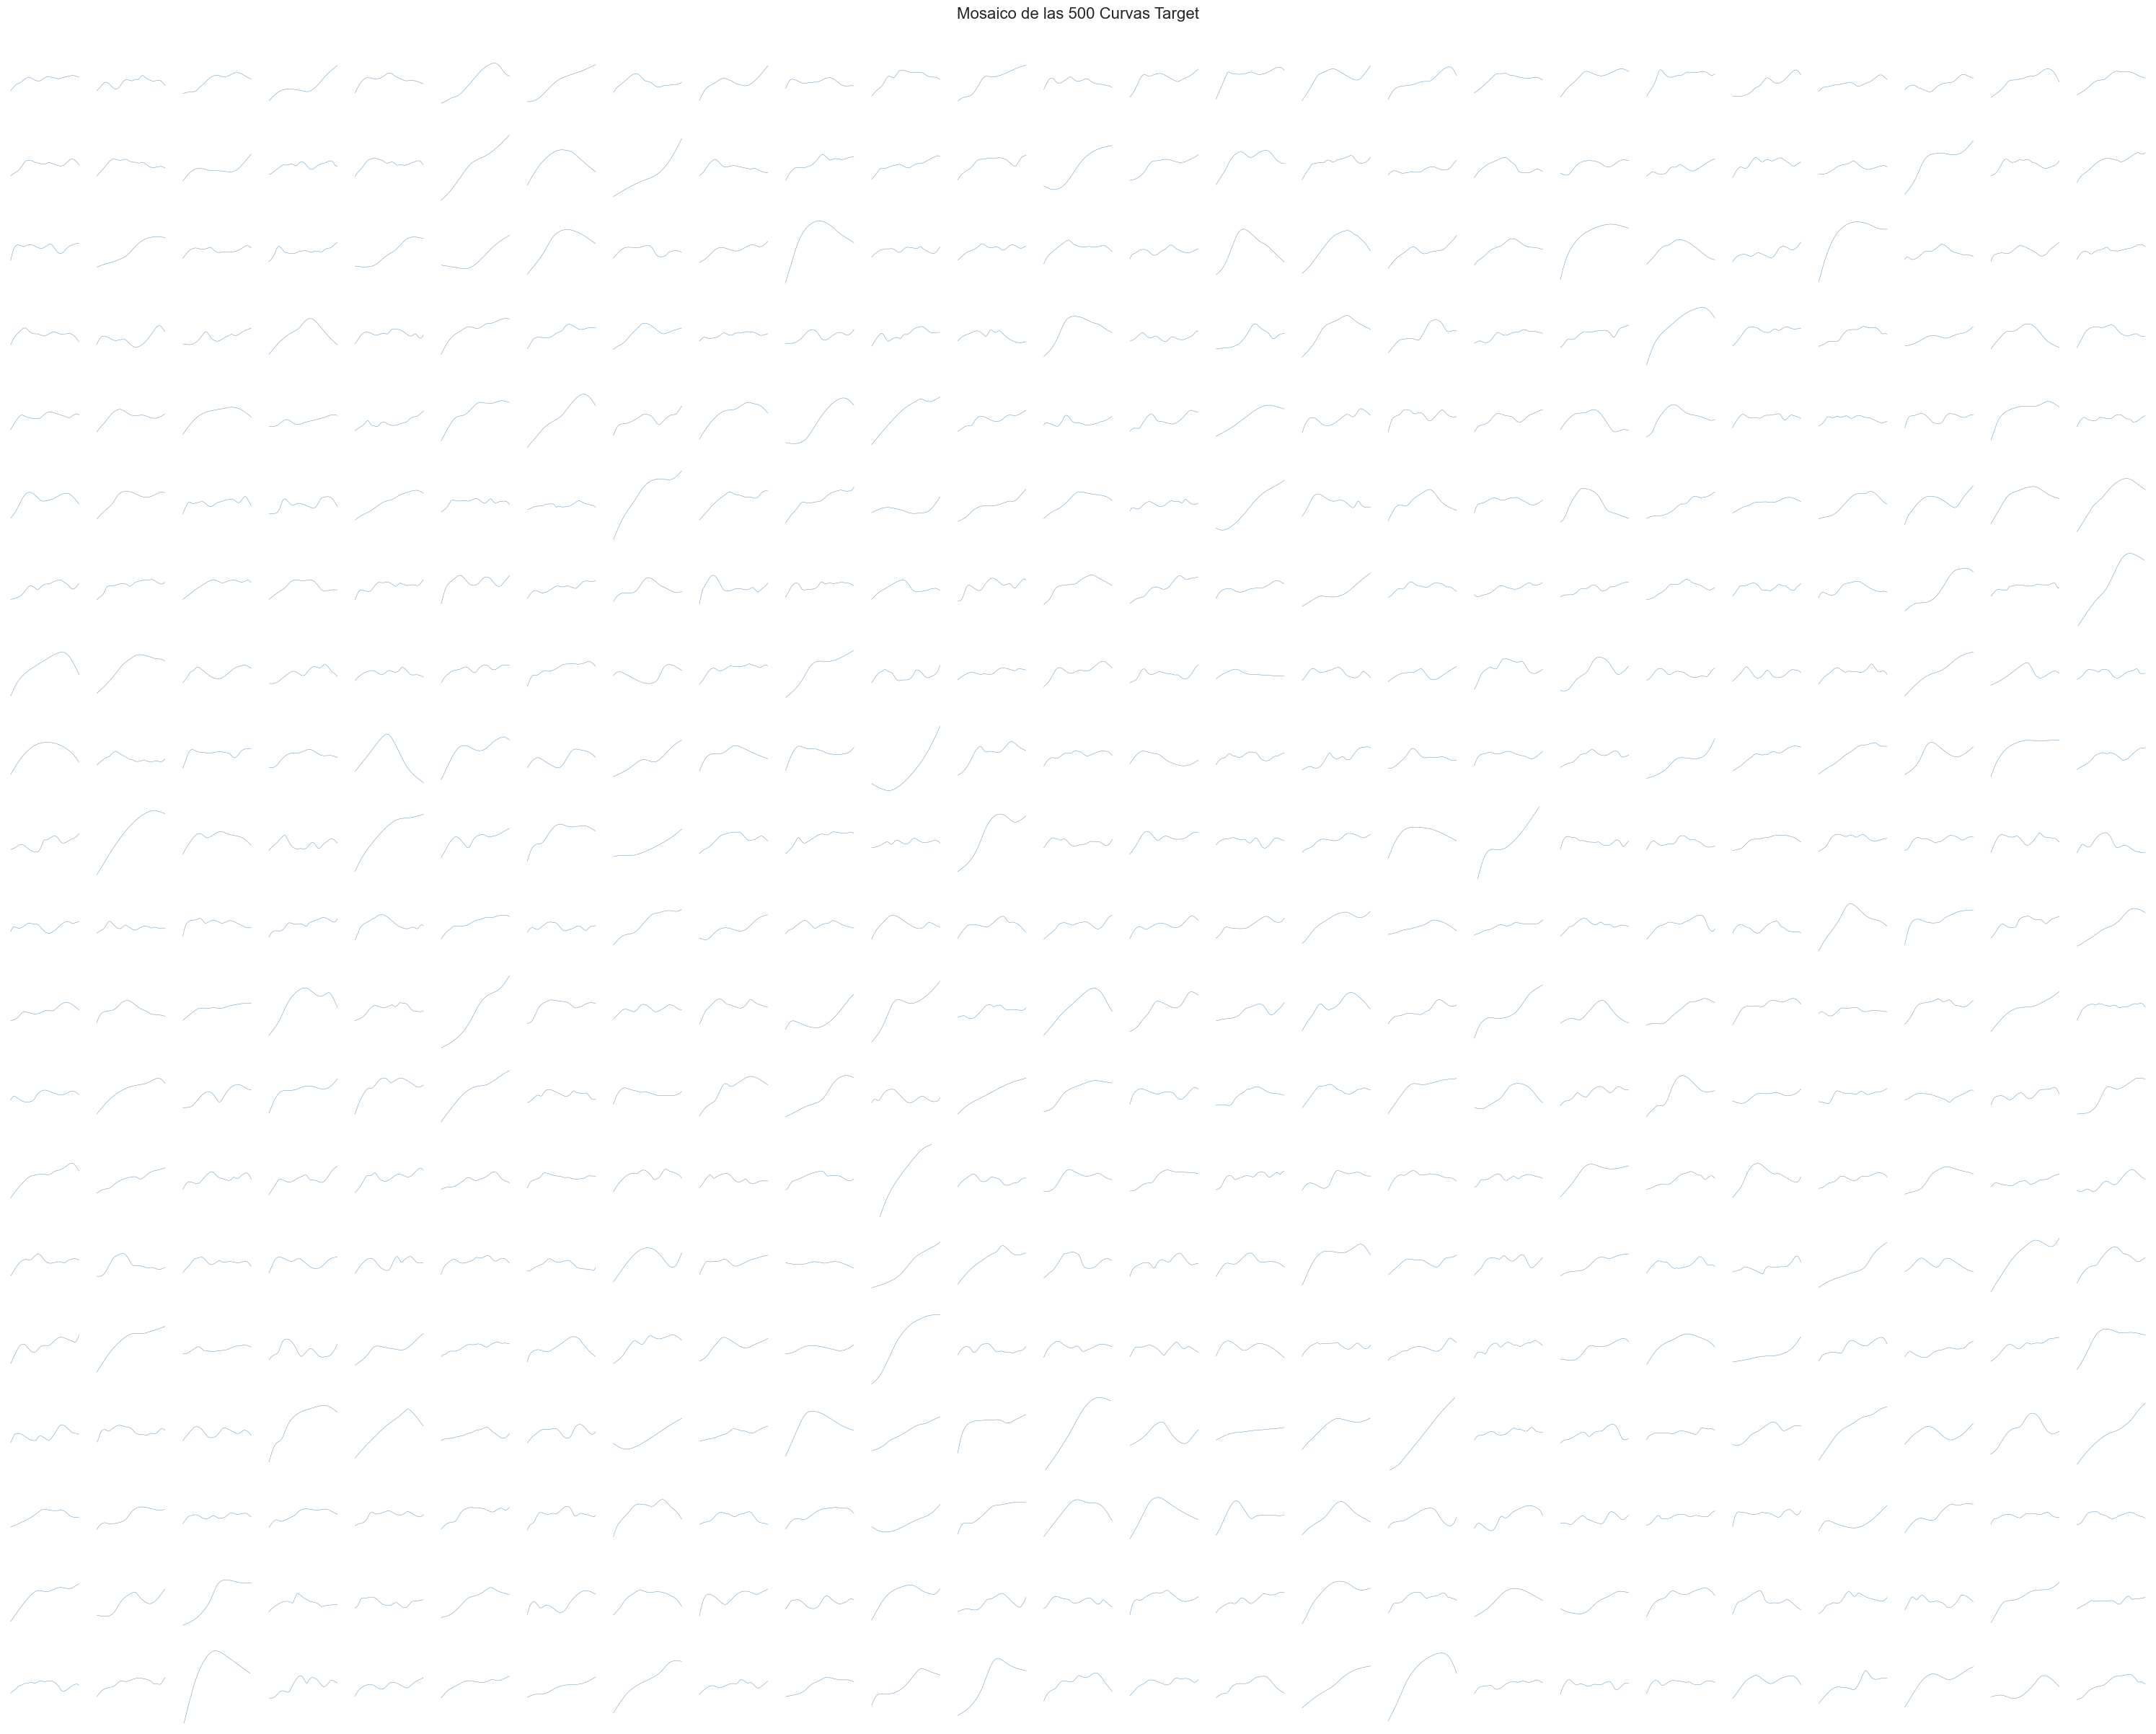

Mosaico guardado en 'mosaico_curvas.png'


In [13]:
# Galeria de todas las curvas en miniatura
print("\nGenerando mosaico de todas las curvas...")

# Crear una imagen grande con todas las curvas
n_curves = 500
n_cols = 25
n_rows = 20

fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 24))

for i, curve_id in enumerate(range(1, n_curves + 1)):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    
    x, y = target_data[curve_id]['x'], target_data[curve_id]['y']
    ax.plot(x, y, linewidth=0.3, color='steelblue')
    ax.axis('off')
    ax.set_aspect('equal')

plt.suptitle('Mosaico de las 500 Curvas Target', fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig('mosaico_curvas.png', dpi=200, bbox_inches='tight')
plt.show()
print("Mosaico guardado en 'mosaico_curvas.png'")

---
## 5. Analisis de Densidad y Distribucion Espacial

ANALISIS DE DISTRIBUCION ESPACIAL


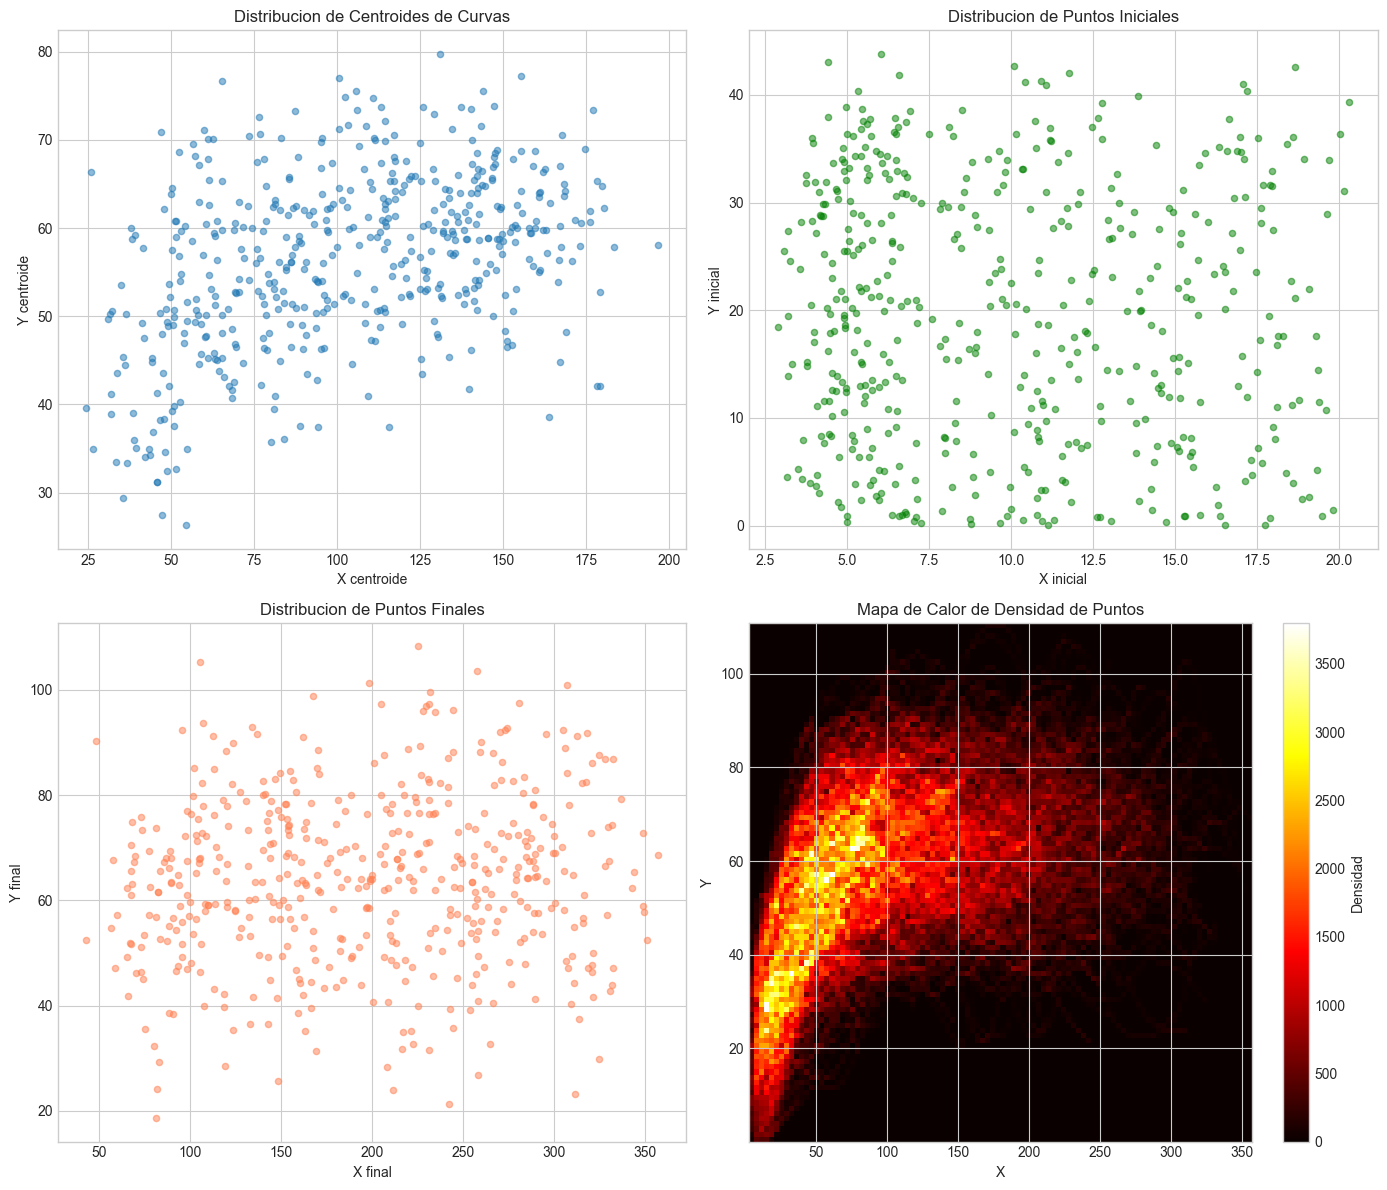

In [14]:
print("ANALISIS DE DISTRIBUCION ESPACIAL")
print("=" * 70)

# Combinar todos los centroides
centroids_x = [target_data[i]['x'].mean() for i in range(1, 501)]
centroids_y = [target_data[i]['y'].mean() for i in range(1, 501)]

# Puntos inicial y final
start_x = [target_data[i]['x'][0] for i in range(1, 501)]
start_y = [target_data[i]['y'][0] for i in range(1, 501)]
end_x = [target_data[i]['x'][-1] for i in range(1, 501)]
end_y = [target_data[i]['y'][-1] for i in range(1, 501)]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Distribucion de centroides
axes[0, 0].scatter(centroids_x, centroids_y, alpha=0.5, s=20)
axes[0, 0].set_title('Distribucion de Centroides de Curvas')
axes[0, 0].set_xlabel('X centroide')
axes[0, 0].set_ylabel('Y centroide')

# Distribucion de puntos iniciales
axes[0, 1].scatter(start_x, start_y, alpha=0.5, s=20, color='green')
axes[0, 1].set_title('Distribucion de Puntos Iniciales')
axes[0, 1].set_xlabel('X inicial')
axes[0, 1].set_ylabel('Y inicial')

# Distribucion de puntos finales
axes[1, 0].scatter(end_x, end_y, alpha=0.5, s=20, color='coral')
axes[1, 0].set_title('Distribucion de Puntos Finales')
axes[1, 0].set_xlabel('X final')
axes[1, 0].set_ylabel('Y final')

# Mapa de calor de todos los puntos
all_x = np.concatenate([target_data[i]['x'] for i in range(1, 501)])
all_y = np.concatenate([target_data[i]['y'] for i in range(1, 501)])

h, xedges, yedges = np.histogram2d(all_x, all_y, bins=100)
im = axes[1, 1].imshow(h.T, origin='lower', aspect='auto', 
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap='hot')
axes[1, 1].set_title('Mapa de Calor de Densidad de Puntos')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
plt.colorbar(im, ax=axes[1, 1], label='Densidad')

plt.tight_layout()
plt.savefig('distribucion_espacial.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Comparativa Multi-Resolucion

COMPARATIVA MULTI-RESOLUCION


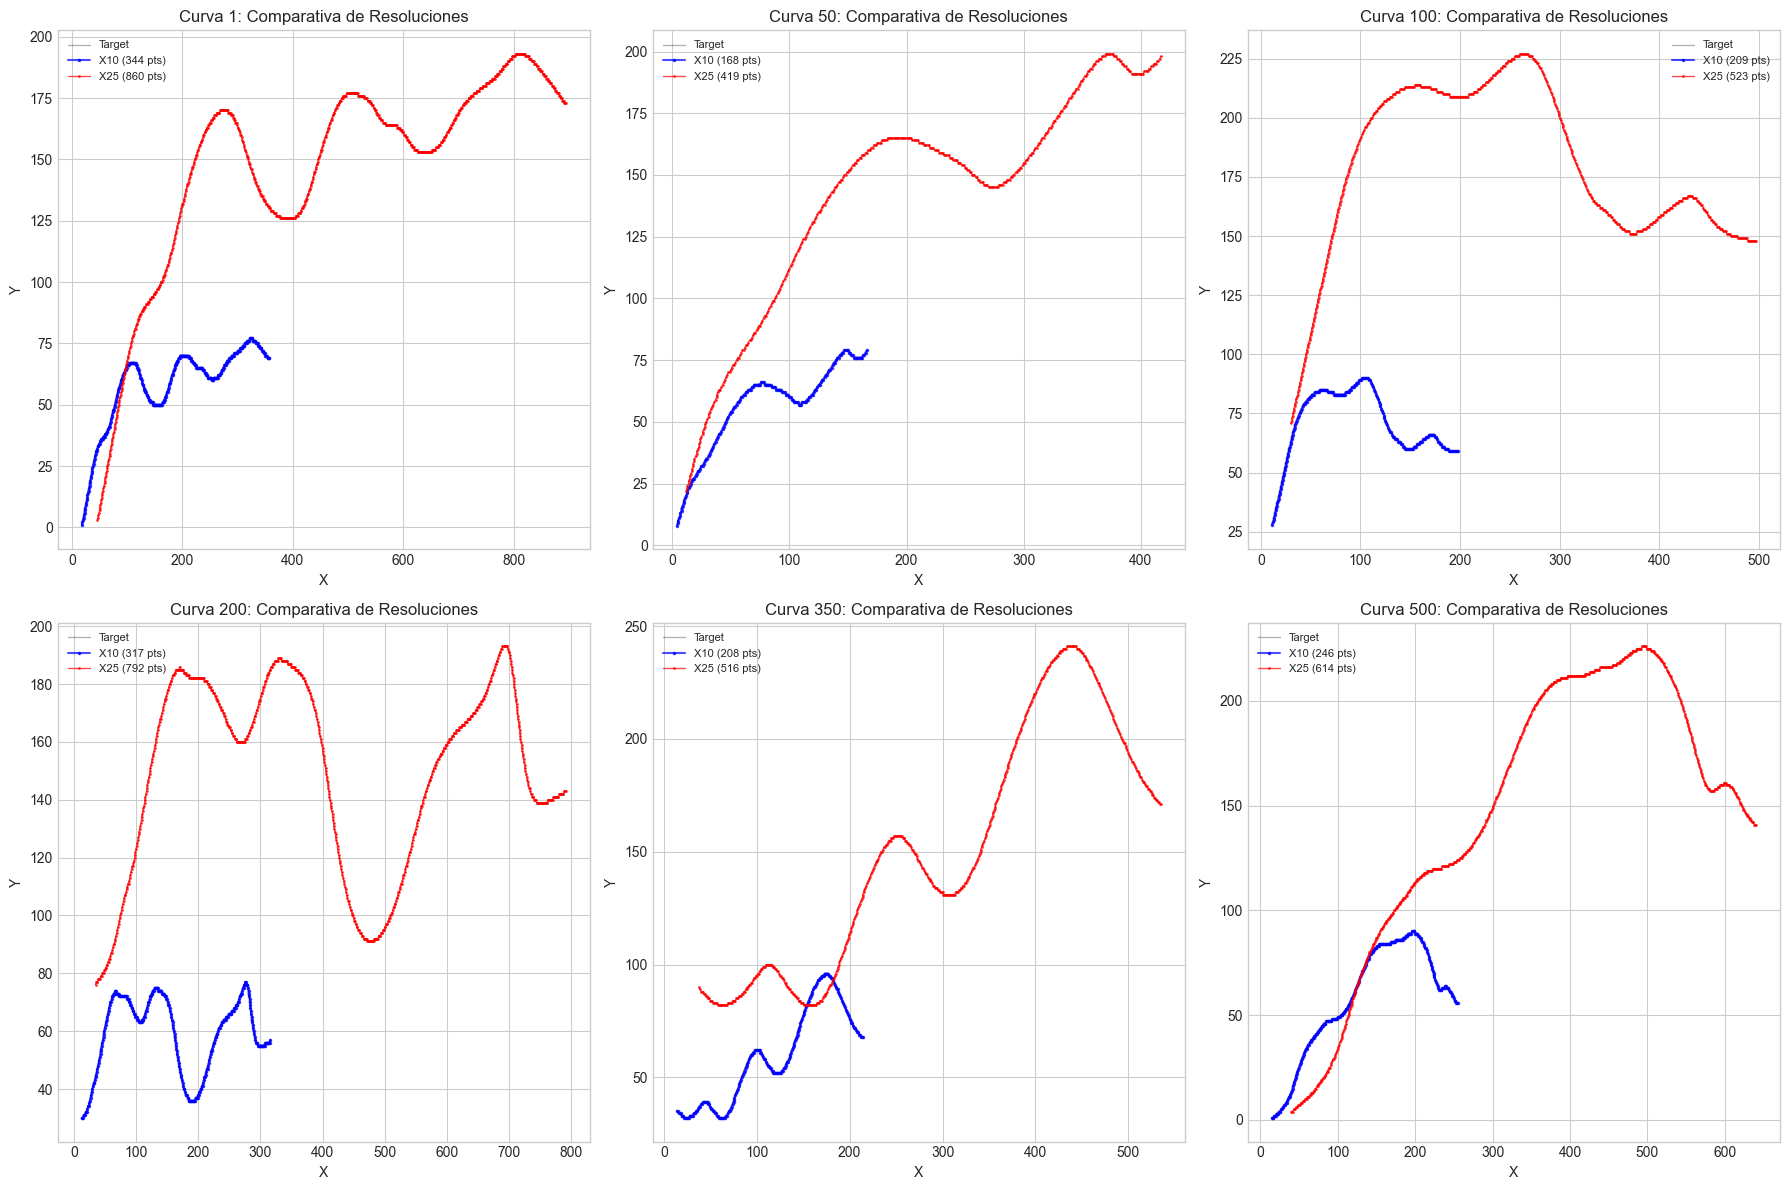

In [15]:
print("COMPARATIVA MULTI-RESOLUCION")
print("=" * 70)

# Seleccionar curvas para comparacion
compare_ids = [1, 50, 100, 200, 350, 500]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, curve_id in enumerate(compare_ids):
    ax = axes[idx // 3, idx % 3]
    
    # Target
    t_x, t_y = target_data[curve_id]['x'], target_data[curve_id]['y']
    ax.plot(t_x, t_y, 'k-', linewidth=1, alpha=0.3, label='Target')
    
    # Pixel X10 y X25
    p10_x, p10_y = pixel_data[10][curve_id]['x'], pixel_data[10][curve_id]['y']
    p25_x, p25_y = pixel_data[25][curve_id]['x'], pixel_data[25][curve_id]['y']
    
    ax.plot(p10_x, p10_y, 'b-', linewidth=1.5, alpha=0.7, marker='.', markersize=3, label=f'X10 ({len(p10_x)} pts)')
    ax.plot(p25_x, p25_y, 'r-', linewidth=1, alpha=0.7, marker='.', markersize=2, label=f'X25 ({len(p25_x)} pts)')
    
    ax.set_title(f'Curva {curve_id}: Comparativa de Resoluciones')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('comparativa_multiresolucion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Metricas de Error Pixel vs Target

In [16]:
def calculate_hausdorff_distance(curve1_x, curve1_y, curve2_x, curve2_y, sample_size=500):
    """Calcula distancia de Hausdorff aproximada entre dos curvas."""
    # Muestrear para eficiencia
    idx1 = np.linspace(0, len(curve1_x)-1, min(sample_size, len(curve1_x))).astype(int)
    idx2 = np.linspace(0, len(curve2_x)-1, min(sample_size, len(curve2_x))).astype(int)
    
    points1 = np.column_stack([curve1_x[idx1], curve1_y[idx1]])
    points2 = np.column_stack([curve2_x[idx2], curve2_y[idx2]])
    
    # Distancias de puntos1 a puntos2
    dists_1_to_2 = spatial.distance.cdist(points1, points2).min(axis=1)
    # Distancias de puntos2 a puntos1
    dists_2_to_1 = spatial.distance.cdist(points2, points1).min(axis=1)
    
    # Hausdorff es el maximo de ambas
    hausdorff = max(dists_1_to_2.max(), dists_2_to_1.max())
    
    return hausdorff, dists_1_to_2.mean(), dists_2_to_1.mean()

print("METRICAS DE ERROR PIXEL vs TARGET")
print("=" * 70)

# Calcular errores para cada variante
error_stats = defaultdict(list)

print("\nCalculando distancias de Hausdorff (esto puede tardar)...")
for x_val in x_values:
    print(f"  Procesando X{x_val}...")
    for curve_id in range(1, 501):
        t_x, t_y = target_data[curve_id]['x'], target_data[curve_id]['y']
        p_x, p_y = pixel_data[x_val][curve_id]['x'], pixel_data[x_val][curve_id]['y']
        
        hausdorff, mean_t2p, mean_p2t = calculate_hausdorff_distance(t_x, t_y, p_x, p_y)
        
        error_stats[x_val].append({
            'curve_id': curve_id,
            'hausdorff': hausdorff,
            'mean_target_to_pixel': mean_t2p,
            'mean_pixel_to_target': mean_p2t
        })

df_errors = {x: pd.DataFrame(error_stats[x]) for x in x_values}

METRICAS DE ERROR PIXEL vs TARGET

Calculando distancias de Hausdorff (esto puede tardar)...
  Procesando X10...
  Procesando X15...
  Procesando X18...
  Procesando X21...
  Procesando X25...


In [17]:
# Resumen de errores
print("\nResumen de errores por variante:")
print("-" * 80)
print(f"{'Variante':>10} | {'Hausdorff Mean':>15} | {'Hausdorff Max':>14} | {'Mean Dist':>12}")
print("-" * 80)

for x_val in x_values:
    df = df_errors[x_val]
    print(f"{'X'+str(x_val):>10} | {df['hausdorff'].mean():>15.4f} | {df['hausdorff'].max():>14.4f} | {df['mean_target_to_pixel'].mean():>12.4f}")


Resumen de errores por variante:
--------------------------------------------------------------------------------
  Variante |  Hausdorff Mean |  Hausdorff Max |    Mean Dist
--------------------------------------------------------------------------------
       X10 |          0.9029 |         0.9929 |       0.4394
       X15 |        105.0602 |       182.4726 |      18.6363
       X18 |        168.0973 |       291.5134 |      26.7256
       X21 |        231.1388 |       400.5545 |      33.9469
       X25 |        315.1805 |       547.2515 |      42.4274


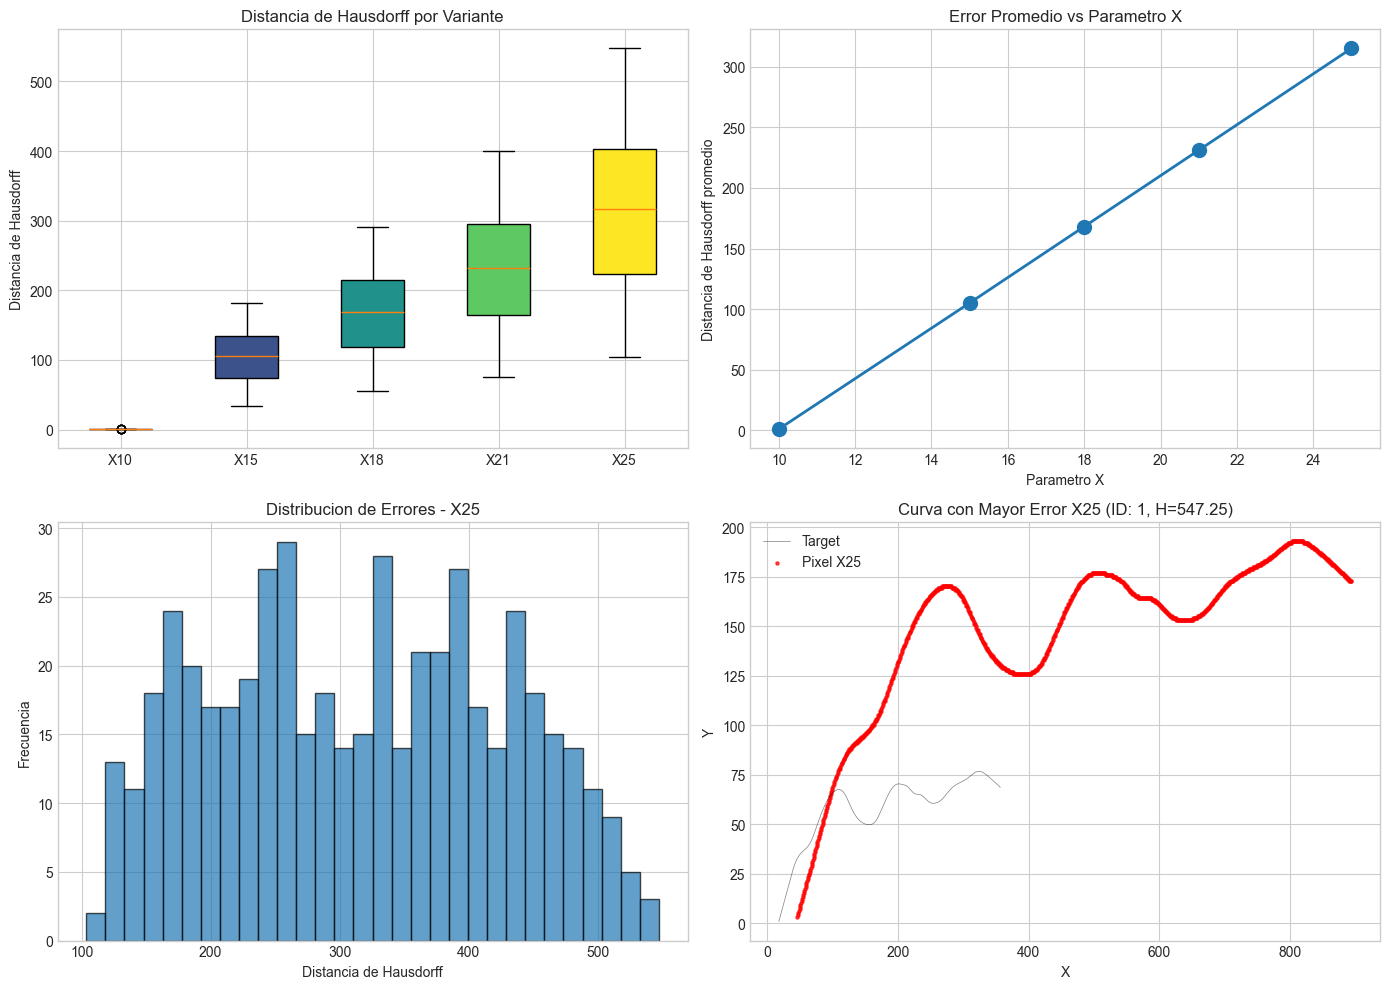

In [18]:
# Visualizacion de errores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot de Hausdorff por variante
hausdorff_data = [df_errors[x]['hausdorff'] for x in x_values]
bp1 = axes[0, 0].boxplot(hausdorff_data, labels=[f'X{x}' for x in x_values], patch_artist=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(x_values)))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 0].set_title('Distancia de Hausdorff por Variante')
axes[0, 0].set_ylabel('Distancia de Hausdorff')

# Tendencia de error promedio
mean_hausdorff = [df_errors[x]['hausdorff'].mean() for x in x_values]
axes[0, 1].plot(x_values, mean_hausdorff, 'o-', linewidth=2, markersize=10)
axes[0, 1].set_title('Error Promedio vs Parametro X')
axes[0, 1].set_xlabel('Parametro X')
axes[0, 1].set_ylabel('Distancia de Hausdorff promedio')
axes[0, 1].grid(True)

# Histograma de errores X25 (mejor resolucion)
axes[1, 0].hist(df_errors[25]['hausdorff'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribucion de Errores - X25')
axes[1, 0].set_xlabel('Distancia de Hausdorff')
axes[1, 0].set_ylabel('Frecuencia')

# Curvas con mayor error
df_x25 = df_errors[25]
high_error_id = df_x25.loc[df_x25['hausdorff'].idxmax(), 'curve_id']

t_x, t_y = target_data[high_error_id]['x'], target_data[high_error_id]['y']
p_x, p_y = pixel_data[25][high_error_id]['x'], pixel_data[25][high_error_id]['y']

axes[1, 1].plot(t_x, t_y, 'k-', linewidth=0.5, alpha=0.5, label='Target')
axes[1, 1].scatter(p_x, p_y, s=5, color='red', alpha=0.7, label='Pixel X25')
axes[1, 1].set_title(f'Curva con Mayor Error X25 (ID: {int(high_error_id)}, H={df_x25["hausdorff"].max():.2f})')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('errores_pixel_target.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones del Analisis de Anomalias y Calidad

### Hallazgos Principales:

1. **Outliers Estadisticos:**
   - Pocas curvas presentan caracteristicas outlier
   - Los outliers identificados tienen caracteristicas geometricas extremas pero son validos

2. **Calidad de Discretizacion:**
   - Todos los valores en pixel_curves son enteros (como se esperaba)
   - El ratio de compresion escala linealmente con el parametro X
   - Presencia de "saltos" en la discretizacion es normal y esperada

3. **Anomalias:**
   - No se detectaron NaN ni valores infinitos
   - No se detectaron puntos duplicados consecutivos significativos
   - Dataset con buena integridad

4. **Errores de Discretizacion:**
   - Mayor X (resolucion) = menor error de Hausdorff
   - X25 proporciona la mejor aproximacion al target
   - Errores son consistentes entre curvas

5. **Distribucion Espacial:**
   - Curvas bien distribuidas en el espacio
   - Centroides y puntos inicial/final muestran patrones consistentes